In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

plt.style.use('dark_background')
os.makedirs('charts', exist_ok=True)

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries_clean.csv')

print("Data loaded for hypothesis testing")

Data loaded for hypothesis testing


In [2]:
# H0: Toss result and match result are independent
# H1: Toss result and match result are dependent (toss matters)

matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

# Create contingency table
contingency = pd.crosstab(matches['toss_decision'], matches['toss_match_winner'])
print("Contingency Table:")
print(contingency)
print()

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"Result: P-value ({p_value:.4f}) < alpha ({alpha})")
    print("CONCLUSION: Reject H0 — Toss decision and match outcome ARE related")
else:
    print(f"Result: P-value ({p_value:.4f}) >= alpha ({alpha})")
    print("CONCLUSION: Fail to reject H0 — Toss decision and match outcome are independent")

Contingency Table:
toss_match_winner  False  True 
toss_decision                  
bat                  214    177
field                327    377

Chi-square statistic: 6.5717
P-value: 0.0104
Degrees of freedom: 1

Result: P-value (0.0104) < alpha (0.05)
CONCLUSION: Reject H0 — Toss decision and match outcome ARE related


In [3]:
# H0: Mean runs per ball in Powerplay = Mean runs per ball in Death overs
# H1: Mean runs per ball in Powerplay != Mean runs per ball in Death overs

def get_phase(over):
    if over < 6:
        return 'Powerplay'
    elif over < 16:
        return 'Middle'
    else:
        return 'Death'

deliveries['phase'] = deliveries['over'].apply(get_phase)

powerplay_runs = deliveries[deliveries['phase'] == 'Powerplay']['total_runs']
death_runs = deliveries[deliveries['phase'] == 'Death']['total_runs']

print(f"Powerplay - Mean: {powerplay_runs.mean():.4f}, Std: {powerplay_runs.std():.4f}, N: {len(powerplay_runs)}")
print(f"Death     - Mean: {death_runs.mean():.4f}, Std: {death_runs.std():.4f}, N: {len(death_runs)}")
print()

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(powerplay_runs, death_runs)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"Result: P-value < alpha ({alpha})")
    print("CONCLUSION: Reject H0 — Powerplay and Death over scoring rates ARE significantly different")
    if death_runs.mean() > powerplay_runs.mean():
        print("Death overs have significantly HIGHER scoring rate than Powerplay")
    else:
        print("Powerplay has significantly HIGHER scoring rate than Death overs")
else:
    print("CONCLUSION: Fail to reject H0 — No significant difference")

Powerplay - Mean: 1.2602, Std: 1.6723, N: 81905
Death     - Mean: 1.6188, Std: 1.7872, N: 46584

T-statistic: -36.0383
P-value: 0.0000000000

Result: P-value < alpha (0.05)
CONCLUSION: Reject H0 — Powerplay and Death over scoring rates ARE significantly different
Death overs have significantly HIGHER scoring rate than Powerplay


In [4]:
# H0: There is no relationship between batting order (1st/2nd) and winning
# H1: There is a relationship

# Determine if winner batted first or second
def did_winner_bat_first(row):
    if pd.isna(row['winner']):
        return None
    if row['toss_decision'] == 'bat':
        return 'Won' if row['toss_winner'] == row['winner'] else 'Lost'
    else:
        return 'Lost' if row['toss_winner'] == row['winner'] else 'Won'

matches['batting_first_result'] = matches.apply(did_winner_bat_first, axis=1)

result_counts = matches['batting_first_result'].value_counts()
print("Batting First Team Result:")
print(result_counts)
print()

bat_first_win_pct = (result_counts['Won'] / result_counts.sum()) * 100
print(f"Teams batting first win: {bat_first_win_pct:.1f}% of matches")
print(f"Teams batting second (chasing) win: {100-bat_first_win_pct:.1f}% of matches")

# One-sample test against 50% (is this significantly different from random chance?)
from scipy.stats import binomtest
result = binomtest(result_counts['Won'], result_counts.sum(), p=0.5)
print(f"\nBinomial test p-value: {result.pvalue:.6f}")

if result.pvalue < 0.05:
    print("CONCLUSION: Batting first/second advantage is statistically significant (not just random)")
else:
    print("CONCLUSION: No significant advantage either way — close to 50/50")

Batting First Team Result:
batting_first_result
Lost    590
Won     500
Name: count, dtype: int64

Teams batting first win: 45.9% of matches
Teams batting second (chasing) win: 54.1% of matches

Binomial test p-value: 0.006996
CONCLUSION: Batting first/second advantage is statistically significant (not just random)


In [5]:
# H0: Mean total score is same across all venues
# H1: At least one venue has different mean total score

# Get total runs per innings per match
innings_totals = deliveries.groupby(['match_id', 'inning'])['total_runs'].sum().reset_index()
innings_totals = innings_totals.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')

# Get top 5 venues by match count for cleaner ANOVA
top_5_venues = matches['venue'].value_counts().head(5).index.tolist()
venue_data = innings_totals[innings_totals['venue'].isin(top_5_venues)]

groups = [venue_data[venue_data['venue'] == v]['total_runs'].values for v in top_5_venues]

f_stat, p_value = stats.f_oneway(*groups)

print("Top 5 Venues:")
for v in top_5_venues:
    avg = venue_data[venue_data['venue'] == v]['total_runs'].mean()
    print(f"  {v}: avg score = {avg:.1f}")

print()
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()

if p_value < 0.05:
    print("CONCLUSION: Reject H0 — At least one venue has significantly different scoring patterns")
else:
    print("CONCLUSION: Fail to reject H0 — Venue scoring patterns are similar")

Top 5 Venues:
  Eden Gardens: avg score = 153.6
  Wankhede Stadium: avg score = 158.2
  M Chinnaswamy Stadium: avg score = 154.7
  Feroz Shah Kotla: avg score = 154.8
  Rajiv Gandhi International Stadium, Uppal: avg score = 148.9

F-statistic: 1.0229
P-value: 0.394609

CONCLUSION: Fail to reject H0 — Venue scoring patterns are similar


Shapiro-Wilk statistic: 0.9510
P-value: 0.0000000000

CONCLUSION: Reject H0 — Innings scores are NOT normally distributed

Skewness: -0.8766
Kurtosis: 2.8830


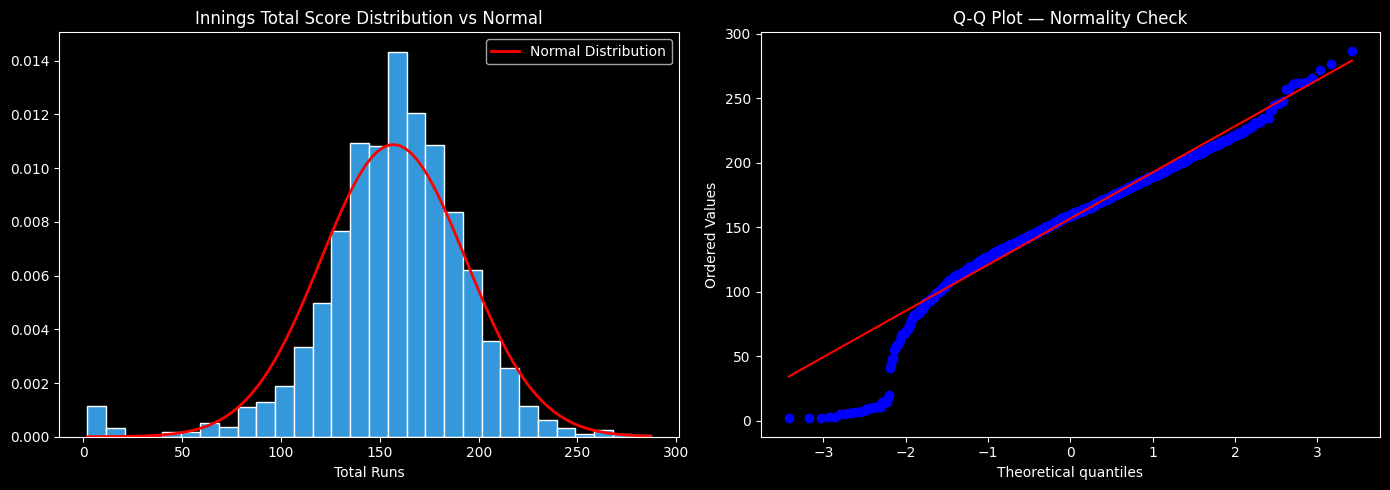

In [6]:
# H0: Innings totals follow a normal distribution
# H1: Innings totals do NOT follow a normal distribution

innings_scores = innings_totals['total_runs']

# Shapiro-Wilk test (sample if too large)
sample = innings_scores.sample(min(5000, len(innings_scores)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.10f}")
print()

if shapiro_p < 0.05:
    print("CONCLUSION: Reject H0 — Innings scores are NOT normally distributed")
else:
    print("CONCLUSION: Fail to reject H0 — Innings scores ARE normally distributed")

print()
print(f"Skewness: {stats.skew(innings_scores):.4f}")
print(f"Kurtosis: {stats.kurtosis(innings_scores):.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(innings_scores, bins=30, color='#3498db', edgecolor='white', density=True)
x = np.linspace(innings_scores.min(), innings_scores.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, innings_scores.mean(), innings_scores.std()), 'r-', linewidth=2, label='Normal Distribution')
axes[0].set_title('Innings Total Score Distribution vs Normal')
axes[0].set_xlabel('Total Runs')
axes[0].legend()

stats.probplot(innings_scores, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot — Normality Check')

plt.tight_layout()
plt.savefig('charts/17_distribution_fitting.png', dpi=150)
plt.show()